In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Structured runtime data
data = [
    # configuration, direction, parallelism, variant, seconds
    ("top down non parallel", "Top-down", "Non-parallel", "Nothing", 51.9405138),
    ("top down parallel", "Top-down", "Parallel", "Nothing", 28.9794975),

    ("top down cached non parallel", "Top-down", "Non-parallel", "Cache", 19.3636054),
    ("top down cached parallel", "Top-down", "Parallel", "Cache", 9.4939428),

    ("top down cache non parallel best rhs", "Top-down", "Non-parallel", "Best RHS", 10.4473404),
    ("top down cache parallel best rhs", "Top-down", "Parallel", "Best RHS", 7.3425462),

    ("bottom up non parallel", "Bottom-up", "Non-parallel", "Nothing", 11.8633357),
    ("bottom up parallel", "Bottom-up", "Parallel", "Nothing", 8.9658317),

    ("bottom up cache non parallel", "Bottom-up", "Non-parallel", "Cache", 10.344676),
    ("bottom up cache parallel", "Bottom-up", "Parallel", "Cache", 5.8175813),

    # This was repeated in your data, so we keep it as a second measurement
    ("bottom up cache non parallel best rhs", "Bottom-up", "Non-parallel", "Best RHS", 3.6206949),

    ("bottom up cache parallel best rhs", "Bottom-up", "Parallel", "Best RHS", 3.2118221),
]

df = pd.DataFrame(
    data,
    columns=["configuration", "direction", "parallelism", "variant", "seconds"]
)

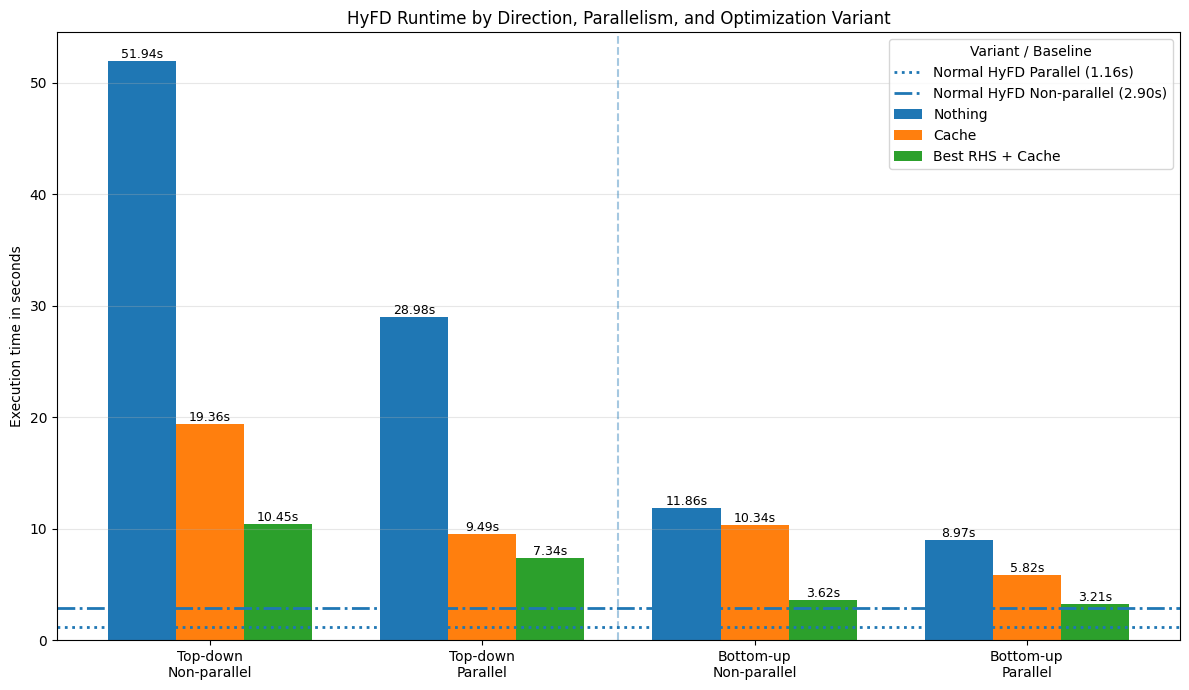

In [2]:
# Aggregate repeated measurements using the mean
# You can change mean to min if you want "best observed runtime"
df.loc[df["variant"] == "Best RHS", "variant"] = "Best RHS + Cache"


grouped = (
    df
    .groupby(["direction", "parallelism", "variant"], as_index=False)
    .agg(
        seconds=("seconds", "mean"),
        runs=("seconds", "count")
    )
)

direction_order = ["Top-down", "Bottom-up"]
parallelism_order = ["Non-parallel", "Parallel"]
variant_order = ["Nothing", "Cache", "Best RHS + Cache"]

grouped["direction"] = pd.Categorical(grouped["direction"], direction_order, ordered=True)
grouped["parallelism"] = pd.Categorical(grouped["parallelism"], parallelism_order, ordered=True)
grouped["variant"] = pd.Categorical(grouped["variant"], variant_order, ordered=True)

grouped = grouped.sort_values(["direction", "parallelism", "variant"])

pivot = grouped.pivot_table(
    index=["direction", "parallelism"],
    columns="variant",
    values="seconds",
    observed=False
).reindex(
    pd.MultiIndex.from_product(
        [direction_order, parallelism_order],
        names=["direction", "parallelism"]
    )
)

# Grouped bar chart:
# first grouping: Top-down / Bottom-up
# second grouping: Parallel / Non-parallel
# bars inside each group: Nothing / Cache / Best RHS

x = np.arange(len(pivot.index))
bar_width = 0.25

plt.figure(figsize=(12, 7))

for i, variant in enumerate(variant_order):
    values = pivot[variant]
    offset = (i - 1) * bar_width

    bars = plt.bar(
        x + offset,
        values,
        width=bar_width,
        label=variant
    )

    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.2f}s",
                ha="center",
                va="bottom",
                fontsize=9
            )

x_labels = [
    f"{direction}\n{parallelism}"
    for direction, parallelism in pivot.index
]

plt.xticks(x, x_labels)
plt.ylabel("Execution time in seconds")
plt.title("HyFD Runtime by Direction, Parallelism, and Optimization Variant")
plt.grid(axis="y", alpha=0.3)

# Normal HyFD baselines
normal_hyfd_parallel = 1.1625754
normal_hyfd_non_parallel = 2.9036356

plt.axhline(
    normal_hyfd_parallel,
    linestyle=":",
    linewidth=2,
    label=f"Normal HyFD Parallel ({normal_hyfd_parallel:.2f}s)"
)

plt.axhline(
    normal_hyfd_non_parallel,
    linestyle="-.",
    linewidth=2,
    label=f"Normal HyFD Non-parallel ({normal_hyfd_non_parallel:.2f}s)"
)

# Visual separator between Top-down and Bottom-up
plt.axvline(1.5, linestyle="--", alpha=0.4)

plt.legend(title="Variant / Baseline")
plt.tight_layout()
plt.show()